# The Arenstorf orbit as an adaptive plant model

A closed-loop simulation calls its plant model once per sampling interval and needs the state at
the end of it to a stated accuracy, whatever the dynamics do in between. `si.adaptive` builds that
map from a model, $S(x, u, \Delta t) \to x(\Delta t)$: an embedded Runge-Kutta pair with step-size
control, the whole integration inside one generated `while_loop`. This notebook runs it on the
Arenstorf orbit, a periodic orbit of the restricted three-body problem that passes close to the
moon, where the step size must fall by orders of magnitude, and checks it against SciPy's
`solve_ivp`.

| Scaly feature | Where |
| --- | --- |
| `si.adaptive(model, "dopri5" / "bs32", rtol=, atol=)` | the tolerance sweep |
| `max_steps=`, and NaN when the budget runs out | the step budget |
| `dt=None` (the interval an input) or a fixed `dt=` | the sampled plant |
| `sc.jacobian` through the `while_loop` | the derivative |
| `si.explicit(model, "dopri5", dt=None, steps=)` | fixed steps |
| `write_module` | the generated C |

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "adaptive_plant"

## The restricted three-body problem

A light body moves in the plane of the earth (mass $1 - \mu$, at $(-\mu, 0)$) and the moon (mass
$\mu$, at $(1 - \mu, 0)$), in the frame rotating with them. With $x = (y_1, y_2, v_1, v_2)$,
distances $r_1$ to the earth and $r_2$ to the moon, and a thrust acceleration $u$,

$$
\begin{aligned}
\dot v_1 &= y_1 + 2 v_2 - (1 - \mu) \frac{y_1 + \mu}{r_1^3} - \mu \frac{y_1 - 1 + \mu}{r_2^3} + u_1, \\
\dot v_2 &= y_2 - 2 v_1 - (1 - \mu) \frac{y_2}{r_1^3} - \mu \frac{y_2}{r_2^3} + u_2 .
\end{aligned}
$$

With $\mu = 0.012277471$ and $u = 0$, the orbit from $x_0 = (0.994, 0, 0, -2.00158510637908\ldots)$
is periodic with $T = 17.0652165601579\ldots$, Hairer, Norsett and Wanner's test problem for step-size
control. The thrust makes the model a plant with an input, `f(x, u) -> xdot`; it stays zero here.
The reference is `solve_ivp` with DOP853 at $10^{-13}$.

In [2]:
MU = 0.012277471
EARTH, MOON = np.array([-MU, 0.0]), np.array([1.0 - MU, 0.0])
X0 = np.array([0.994, 0.0, 0.0, -2.00158510637908252240537862224])
PERIOD = 17.0652165601579625588917206249
NO_THRUST = np.zeros(2)


@sc.function(4, 2, output="xdot", name="adaptive_plant_arenstorf")
def arenstorf(x, u):
  y, v = x[:2], x[2:]
  d1, d2 = y - sc.const(EARTH), y - sc.const(MOON)
  s1, s2 = (d1 * d1).sum(), (d2 * d2).sum()  # squared distances; s sqrt(s) generates cheaper C than s ** 1.5
  gravity = -(1.0 - MU) * d1 / (s1 * s1.sqrt()) - MU * d2 / (s2 * s2.sqrt())
  return sc.concat([v, y + 2.0 * sc.stack([v[1], -v[0]]) + gravity + u])


def rhs_np(t, x):
  y, v = x[:2], x[2:]
  d1, d2 = y - EARTH, y - MOON
  gravity = -(1.0 - MU) * d1 / np.linalg.norm(d1) ** 3 - MU * d2 / np.linalg.norm(d2) ** 3
  return np.concatenate([v, y + 2.0 * np.array([v[1], -v[0]]) + gravity])


def reference(span, tol=1e-13, method="DOP853", **options):
  return solve_ivp(rhs_np, (0.0, span), X0, method=method, rtol=tol, atol=tol, **options)


orbit = reference(PERIOD, dense_output=True)
exact = orbit.y[:, -1]
reference_closing = np.abs(exact - X0).max()
print(f"the reference closes to {reference_closing:.1e} after one period")

the reference closes to 9.7e-10 after one period


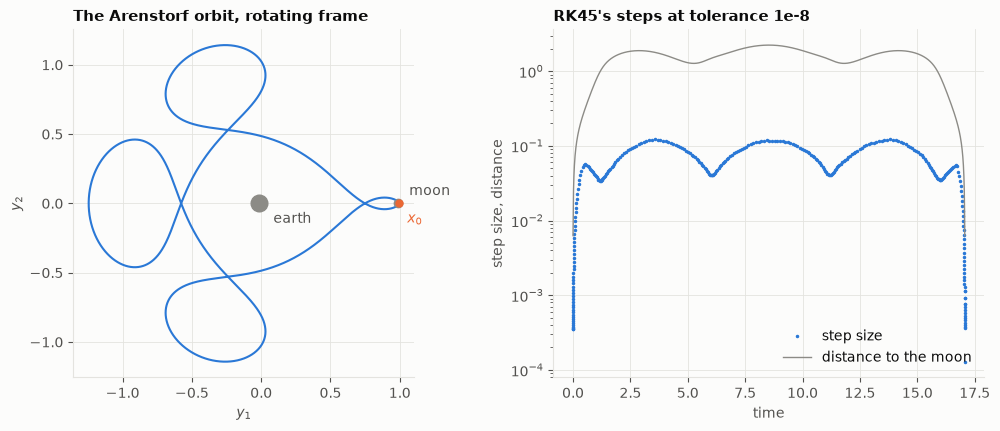

RK45 at 1e-8: 320 steps from 1.3e-04 to 0.12; closest approach to the moon 0.0063


In [3]:
t_plot = np.linspace(0.0, PERIOD, 4000)
y_plot = orbit.sol(t_plot)
rk45_steps = reference(PERIOD, 1e-8, "RK45")
moon_distance = np.hypot(y_plot[0] - MOON[0], y_plot[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
ax1.plot(y_plot[0], y_plot[1], color=plotstyle.BLUE, lw=1.5)
ax1.plot(*EARTH, "o", color=plotstyle.NEUTRAL, ms=12)
ax1.plot(*MOON, "o", color=plotstyle.NEUTRAL, ms=6)
ax1.annotate("earth", EARTH, xytext=(10, -14), textcoords="offset points", color=plotstyle.TEXT_SECONDARY)
ax1.annotate("moon", MOON, xytext=(8, 6), textcoords="offset points", color=plotstyle.TEXT_SECONDARY)
ax1.plot(*X0[:2], "o", color=plotstyle.ORANGE, ms=5)
ax1.annotate("$x_0$", X0[:2], xytext=(6, -14), textcoords="offset points", color=plotstyle.ORANGE)
ax1.set_aspect("equal")
ax1.set_xlabel("$y_1$")
ax1.set_ylabel("$y_2$")
ax1.set_title("The Arenstorf orbit, rotating frame")
ax2.semilogy(rk45_steps.t[1:], np.diff(rk45_steps.t), ".", color=plotstyle.BLUE, ms=3, label="step size")
ax2.semilogy(t_plot, moon_distance, color=plotstyle.NEUTRAL, lw=1, label="distance to the moon")
ax2.set_xlabel("time")
ax2.set_ylabel("step size, distance")
ax2.set_title("RK45's steps at tolerance 1e-8")
ax2.legend(loc="lower right")
plt.show()
steps = np.diff(rk45_steps.t)
print(f"RK45 at 1e-8: {len(steps)} steps from {steps.min():.1e} to {steps.max():.2f}; closest approach to the moon {moon_distance.min():.4f}")

The orbit starts at its closest approach to the moon, 0.0063 from its centre, winds round the
earth and comes back. At tolerance $10^{-8}$ RK45 takes 320 steps, from $1.3 \times 10^{-4}$ near
the moon to 0.12 far from it: the step size follows the distance to the moon over three orders of
magnitude, which no fixed step can do efficiently.

## The adaptive map

`si.adaptive(model, pair, rtol=, atol=)` builds $S(x, u, \Delta t)$, the interval the last input
by default. Each iteration of its `while_loop` carries $(x, t, h)$ and attempts a step of
$h_s = \min(h, \Delta t - t)$ with both solutions of the embedded pair, $\hat x$ of order $p$ and
$\tilde x$ of order $q$ (DOPRI5: 5 and 4; BS32: 3 and 2). The step is accepted when

$$
\mathrm{err} = \sqrt{\frac{1}{n} \sum_i \left(\frac{\hat x_i - \tilde x_i}{\mathrm{atol} + \mathrm{rtol} \max(|x_i|, |\hat x_i|)}\right)^2} \le 1,
$$

and the next attempt is $h \cdot \min(5, \max(0.2,\ 0.9\, \mathrm{err}^{-1/(q+1)}))$, as `solve_ivp`
does. The tolerance bounds each step's local error, not the error at the end: what reaches $x(T)$
depends on how the flow amplifies local errors.

Each tolerance is its own map, compiled on its first call. The time per call is the fastest of a
few, from Python, against `solve_ivp`'s RK45, which uses the same Dormand-Prince pair.

In [4]:
PAIRS = ("dopri5", "bs32")
TOLS = (1e-4, 1e-6, 1e-8, 1e-10)
MAX_STEPS = 200_000  # SciPy's RK23, the same BS32 pair, takes about 18 000 steps at 1e-10
REPEATS = 5


def plant(pair, tol):
  """S(x, u, dt) -> x(dt) with rtol = atol = tol, the interval an input."""
  return si.adaptive(arenstorf, pair, rtol=tol, atol=tol, max_steps=MAX_STEPS, name=f"adaptive_plant_{pair}_{-round(np.log10(tol))}")


def fastest(call, repeats):
  call()
  times = []
  for _ in range(repeats):
    start = time.perf_counter()
    call()
    times.append(time.perf_counter() - start)
  return min(times)


maps = {(pair, tol): plant(pair, tol) for tol in TOLS for pair in PAIRS}
period = np.array(PERIOD)
sweep, rk45 = [], []
for tol in TOLS:
  for pair in PAIRS:
    step = maps[pair, tol]
    end = step(X0, NO_THRUST, period)
    seconds = fastest(lambda step=step: step(X0, NO_THRUST, period), REPEATS)
    error = np.abs(end - exact).max()
    sweep.append((pair, tol, error, error / tol, np.abs(end - X0).max(), seconds))
  sol = reference(PERIOD, tol, "RK45")
  seconds = fastest(lambda tol=tol: reference(PERIOD, tol, "RK45"), 2)
  rk45.append((tol, np.abs(sol.y[:, -1] - exact).max(), len(sol.t) - 1, seconds))

print(f"  {'pair':<7} {'tol':>7} {'error':>9} {'err/tol':>8} {'closing':>9} {'us/call':>8}")
for pair, tol, error, ratio, closing, seconds in sweep:
  print(f"  {pair:<7} {tol:7.0e} {error:9.2e} {ratio:8.1e} {closing:9.2e} {seconds * 1e6:8.0f}")
print(f"  {'RK45':<7} {'tol':>7} {'error':>9} {'steps':>8} {'':>9} {'us/call':>8}")
for tol, error, steps, seconds in rk45:
  print(f"  {'':<7} {tol:7.0e} {error:9.2e} {steps:8d} {'':>9} {seconds * 1e6:8.0f}")

  pair        tol     error  err/tol   closing  us/call
  dopri5    1e-04  1.87e+00  1.9e+04  1.87e+00       17
  bs32      1e-04  1.35e+00  1.4e+04  1.35e+00       27
  dopri5    1e-06  1.14e-02  1.1e+04  1.14e-02       29
  bs32      1e-06  4.96e-02  5.0e+04  4.96e-02       95
  dopri5    1e-08  1.46e-04  1.5e+04  1.46e-04       53
  bs32      1e-08  4.88e-04  4.9e+04  4.88e-04      420
  dopri5    1e-10  3.27e-06  3.3e+04  3.27e-06      117
  bs32      1e-10  4.82e-06  4.8e+04  4.82e-06     1835
  RK45        tol     error    steps            us/call
            1e-04  1.90e+00       60               3965
            1e-06  1.63e-02      132               8408
            1e-08  1.48e-04      320              16704
            1e-10  3.27e-06      794              37412


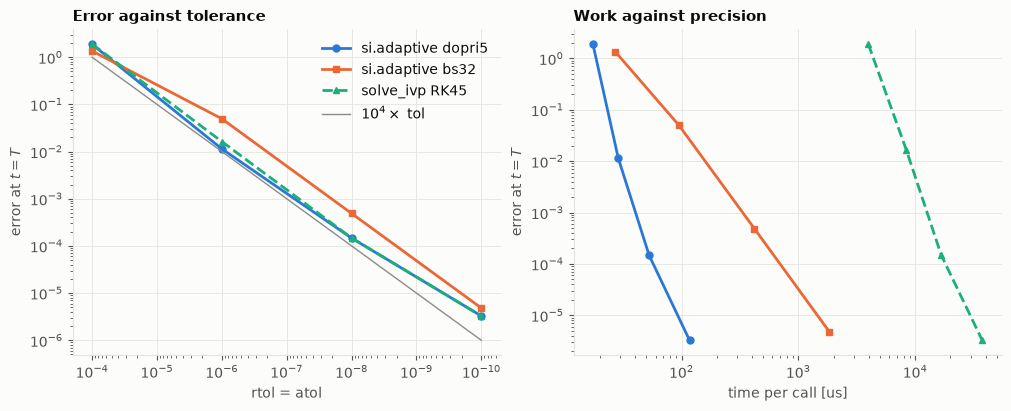

RK45 time / dopri5 time: 227x, 292x, 316x, 320x


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
series = [("dopri5", plotstyle.BLUE, "o"), ("bs32", plotstyle.ORANGE, "s")]
for pair, color, marker in series:
  rows = [row for row in sweep if row[0] == pair]
  ax1.loglog([r[1] for r in rows], [r[2] for r in rows], marker + "-", color=color, label=f"si.adaptive {pair}")
  ax2.loglog([1e6 * r[5] for r in rows], [r[2] for r in rows], marker + "-", color=color, label=f"si.adaptive {pair}")
ax1.loglog([r[0] for r in rk45], [r[1] for r in rk45], "^--", color=plotstyle.AQUA, label="solve_ivp RK45")
ax2.loglog([1e6 * r[3] for r in rk45], [r[1] for r in rk45], "^--", color=plotstyle.AQUA, label="solve_ivp RK45")
tols = np.array(TOLS)
ax1.loglog(tols, 1e4 * tols, color=plotstyle.NEUTRAL, lw=1, label=r"$10^4 \times$ tol")
ax1.invert_xaxis()
ax1.set_xlabel("rtol = atol")
ax1.set_ylabel("error at $t = T$")
ax1.set_title("Error against tolerance")
ax1.legend()
ax2.set_xlabel("time per call [us]")
ax2.set_ylabel("error at $t = T$")
ax2.set_title("Work against precision")
plt.show()
speedup = [r[3] / s[5] for r, s in zip(rk45, [s for s in sweep if s[0] == "dopri5"], strict=True)]
print("RK45 time / dopri5 time:", ", ".join(f"{s:.0f}x" for s in speedup))

At $10^{-4}$ all three lose the orbit, with errors of order 1. From $10^{-6}$ on, the error falls
with the tolerance and stays $1.1 \times 10^4$ to $3.3 \times 10^4$ times it for DOPRI5 and about
$5 \times 10^4$ times it for BS32. The factor belongs to the problem, not to the map: the flow
amplifies the local errors made near the moon, and RK45, the same pair in SciPy, makes the same
errors ($1.6 \times 10^{-2}$, $1.5 \times 10^{-4}$, $3.3 \times 10^{-6}$ against DOPRI5's
$1.1 \times 10^{-2}$, $1.5 \times 10^{-4}$, $3.3 \times 10^{-6}$).

Per call, DOPRI5 takes about 20 to 120 µs where RK45 takes 4 to 40 ms, over 200 times less in
this run (the ratios are printed above the plot). That compares a loop in C with SciPy's stepping loop in Python, which is what a simulation
calling its plant from Python sees, not two compiled kernels. BS32, of third order, needs more
steps for the same error and at $10^{-10}$ costs over 15 times what DOPRI5 does.

## The step budget

`max_steps` bounds the attempted steps, accepted and rejected together; it sizes the loop in the
generated C. When the budget runs out before $t = \Delta t$ the map returns NaN, not the state
where it stopped, so a plant that could not keep up cannot pass for one that did.

In [6]:
SHORT_BUDGET, SHORT_SPAN = 60, 0.5  # at 1e-8, 60 steps reach t = 0.5 but not t = T
short = si.adaptive(arenstorf, rtol=1e-8, atol=1e-8, max_steps=SHORT_BUDGET, name="adaptive_plant_short_budget")
short_budget_period = short(X0, NO_THRUST, period)
short_budget_span = short(X0, NO_THRUST, np.array(SHORT_SPAN))
short_budget_span_error = np.abs(short_budget_span - reference(SHORT_SPAN).y[:, -1]).max()
print(f"max_steps = {SHORT_BUDGET}: x(T) = {short_budget_period}")
print(f"                x({SHORT_SPAN}) = {short_budget_span}, off by {short_budget_span_error:.1e}")

max_steps = 60: x(T) = [nan nan nan nan]
                x(0.5) = [ 0.69178493  0.03724534 -0.57302656  0.42351994], off by 9.7e-08


Sixty steps take the map to $t = 0.5$ within $10^{-7}$ of the reference; over the whole period
they run out and every entry of the result is NaN.

## A plant sampled at a fixed interval

With `dt=None`, the default, the interval is the map's last input. A plant in a closed loop is
called once per sampling interval, and `dt=` folds that interval into the generated code, leaving
$S(x, u)$. A hundred calls, one per sample of the period, should arrive where one call over the
whole period does, to the tolerance: each call restarts the step-size control from $\Delta t / 100$.

In [7]:
SAMPLES = 100
PLANT_TOL = 1e-10
free = maps["dopri5", PLANT_TOL]
sampled = si.adaptive(arenstorf, rtol=PLANT_TOL, atol=PLANT_TOL, max_steps=MAX_STEPS, dt=PERIOD / SAMPLES, name="adaptive_plant_sampled")
free_inputs, sampled_inputs = free.input_names, sampled.input_names
t_samples = PERIOD / SAMPLES * np.arange(SAMPLES + 1)
x_samples = [X0]
for _ in range(SAMPLES):
  x_samples.append(sampled(x_samples[-1], NO_THRUST))
x_samples = np.array(x_samples)
one_call = free(X0, NO_THRUST, period)
sampled_error = np.abs(x_samples[-1] - exact).max()
sampled_vs_one_call = np.abs(x_samples[-1] - one_call).max()
sample_seconds = fastest(lambda: sampled(X0, NO_THRUST), REPEATS)
print(f"inputs with dt=None: {free_inputs}; with dt = T / {SAMPLES}: {sampled_inputs}")
print(f"{SAMPLES} calls: error {sampled_error:.2e} at T, {sampled_vs_one_call:.1e} from one call over T, {sample_seconds * 1e6:.1f} us per call")

inputs with dt=None: ('x', 'u', 'dt'); with dt = T / 100: ('x', 'u')
100 calls: error 2.91e-06 at T, 3.6e-07 from one call over T, 17.6 us per call


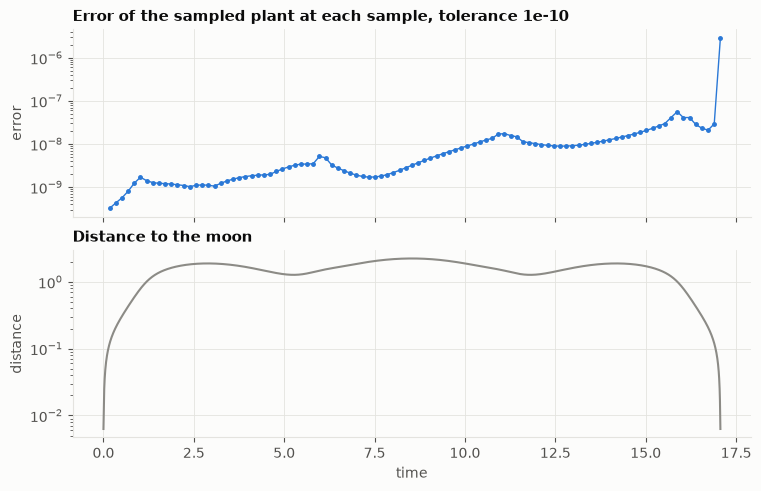

error 2.9e-08 one sample before T, 2.9e-06 at T


In [8]:
sample_error = np.abs(x_samples - orbit.sol(t_samples).T).max(axis=1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 4.8), sharex=True)
ax1.semilogy(t_samples[1:], sample_error[1:], ".-", color=plotstyle.BLUE, lw=1)
ax1.set_ylabel("error")
ax1.set_title("Error of the sampled plant at each sample, tolerance 1e-10")
ax2.semilogy(t_plot, moon_distance, color=plotstyle.NEUTRAL, lw=1.5)
ax2.set_xlabel("time")
ax2.set_ylabel("distance")
ax2.set_title("Distance to the moon")
plt.show()
print(f"error {sample_error[-2]:.1e} one sample before T, {sample_error[-1]:.1e} at T")

The hundred calls end $2.9 \times 10^{-6}$ from the reference and $3.6 \times 10^{-7}$ from the
single call over $T$: the two take different steps, since each call restarts the control from a
step of $\Delta t / 100$, and both are as accurate as the tolerance makes them on this orbit. A
call costs about 18 µs. The error grows slowly along the orbit, from $10^{-9}$ to $3 \times 10^{-8}$,
and the last interval, which ends at the closest approach to the moon, multiplies it by 100.

## The derivative through the loop

`sc.jacobian` of the map in its initial state differentiates through the `while_loop`. The
controller's step factor is rounded to a power of $2^{1/1024}$ through an integer cast, which
carries no derivative, so the derivative is that of the steps actually taken, their sizes frozen.
The exact derivative of the flow, the monodromy matrix $\Phi(T)$, solves the variational equations

$$
\dot \Phi = f_x(x(t))\, \Phi, \qquad \Phi(0) = I,
$$

integrated here by `solve_ivp` beside the state, with $f_x$ written out by hand. The derivative of
the steps taken approximates $\Phi(T)$ to the accuracy of the steps, so the agreement should follow
the tolerance, not rounding.

In [9]:
def variational_np(t, z):
  x, phi = z[:4], z[4:].reshape(4, 4)
  f_x = np.zeros((4, 4))
  f_x[:2, 2:], f_x[2:, :2], f_x[2:, 2:] = np.eye(2), np.eye(2), [[0.0, 2.0], [-2.0, 0.0]]
  for mass, d in ((1.0 - MU, x[:2] - EARTH), (MU, x[:2] - MOON)):
    r = np.linalg.norm(d)
    f_x[2:, :2] -= mass * (np.eye(2) / r**3 - 3.0 * np.outer(d, d) / r**5)
  return np.concatenate([rhs_np(t, x), (f_x @ phi).ravel()])


var = solve_ivp(variational_np, (0.0, PERIOD), np.concatenate([X0, np.eye(4).ravel()]), method="DOP853", rtol=1e-13, atol=1e-13)
monodromy = var.y[4:, -1].reshape(4, 4)
monodromy_max = np.abs(monodromy).max()
jacobian_rel_error = []
for tol in (1e-8, PLANT_TOL):
  jac = sc.jacobian(maps["dopri5", tol], "x")(X0, NO_THRUST, period)
  jacobian_rel_error.append((tol, np.abs(jac - monodromy).max() / monodromy_max))
multipliers = np.sort(np.abs(np.linalg.eigvals(monodromy)))[::-1]
print(f"largest entry of Phi(T): {monodromy_max:.2e}; eigenvalues " + ", ".join(f"{m:.4g}" for m in multipliers))
for tol, rel in jacobian_rel_error:
  print(f"  tol {tol:.0e}: max |dx(T)/dx0 - Phi(T)| / max |Phi(T)| = {rel:.1e}")

largest entry of Phi(T): 2.22e+06; eigenvalues 285.4, 1.001, 0.9993, 0.003504
  tol 1e-08: max |dx(T)/dx0 - Phi(T)| / max |Phi(T)| = 1.6e-04
  tol 1e-10: max |dx(T)/dx0 - Phi(T)| / max |Phi(T)| = 3.2e-06


$\Phi(T)$ has entries up to $2.2 \times 10^6$ and multipliers 285.4 and 0.0035 (a product of 1:
the flow preserves area in phase space) and a pair near 1, a double multiplier that rounding splits
into 0.9993 and 1.001. The derivative through the loop agrees with it to $1.6 \times 10^{-4}$ of
its largest entry at tolerance $10^{-8}$ and $3.2 \times 10^{-6}$ at $10^{-10}$: the same factor of
about $10^4$ over the tolerance as the state itself.

## Fixed steps

The same pair with a fixed step: `si.explicit(model, "dopri5", dt=None, steps=1000)` runs 1000
equal steps as a scan in the generated C, and $k$ calls of it cover the period with $1000 k$ steps.
The fixed step must be small enough for the passes near the moon everywhere along the orbit.
The adaptive map does not report how many steps it took, so the adaptive side of the comparison
is RK45's count, the same pair with the same kind of controller.

   steps     error
    4000  2.07e+00
    8000  1.30e+00
   16000  8.60e-03
   32000  7.95e-05
   64000  3.96e-06


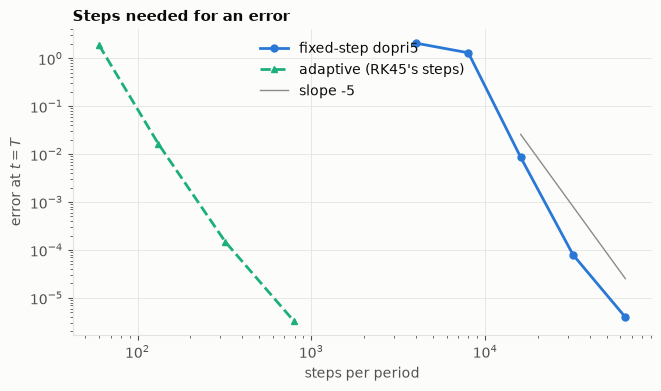

In [10]:
FIXED_CHUNK, FIXED_CALLS = 1000, (4, 8, 16, 32, 64)
fixed = si.explicit(arenstorf, "dopri5", dt=None, steps=FIXED_CHUNK, name="adaptive_plant_fixed_dopri5")
fixed_step_errors = []
for calls in FIXED_CALLS:
  x_fixed = X0
  for _ in range(calls):
    x_fixed = fixed(x_fixed, NO_THRUST, np.array(PERIOD / calls))
  fixed_step_errors.append((calls * FIXED_CHUNK, np.abs(x_fixed - exact).max()))
print(f"  {'steps':>6} {'error':>9}")
for steps, error in fixed_step_errors:
  print(f"  {steps:6d} {error:9.2e}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(*zip(*fixed_step_errors, strict=True), "o-", color=plotstyle.BLUE, label="fixed-step dopri5")
ax.loglog([r[2] for r in rk45], [r[1] for r in rk45], "^--", color=plotstyle.AQUA, label="adaptive (RK45's steps)")
n_ref = np.array([fixed_step_errors[2][0], fixed_step_errors[-1][0]])
ax.loglog(n_ref, 3 * fixed_step_errors[2][1] * (n_ref / n_ref[0]) ** -5.0, color=plotstyle.NEUTRAL, lw=1, label="slope -5")
ax.set_xlabel("steps per period")
ax.set_ylabel("error at $t = T$")
ax.set_title("Steps needed for an error")
ax.legend(loc="upper center")
plt.show()

Fixed-step DOPRI5 has not converged at 8000 steps (error 1.3). From 16 000 steps on its error
falls at the method's fifth order, to $8.0 \times 10^{-5}$ at 32 000 and $4.0 \times 10^{-6}$ at
64 000. The adaptive pair reaches $1.5 \times 10^{-4}$ in 320 steps and $3.3 \times 10^{-6}$ in 794,
about 80 times fewer for the same error: a fixed step small enough for the pass near the moon is
wasted everywhere else.

## Checks

The numbers above, held to tolerances with a margin of about ten over what was measured. The
timings are not checked.

In [11]:
checks = 0
assert reference_closing < 1e-8
checks += 1
for pair in PAIRS:
  rows = [row for row in sweep if row[0] == pair and row[1] <= 1e-6]
  errors = [error for _, _, error, _, _, _ in rows]
  assert all(np.diff(errors) < 0)
  assert all(3e3 < ratio < 2e5 for _, _, _, ratio, _, _ in rows)  # the flow amplifies the local errors by about 1e4
  checks += 2
dopri = {tol: error for pair, tol, error, *_ in sweep if pair == "dopri5"}
assert dopri[1e-10] < 3e-5
checks += 1
for tol, error, _, _ in rk45:
  if tol <= 1e-6:
    assert 0.5 < dopri[tol] / error < 2  # the same pair as SciPy's RK45, the same accuracy
    checks += 1
assert np.isnan(short_budget_period).all()
assert np.isfinite(short_budget_span).all() and short_budget_span_error < 1e-6
assert free_inputs == ("x", "u", "dt") and sampled_inputs == ("x", "u")
assert sampled_error < 3e-5 and sampled_vs_one_call < 4e-6
assert 1e6 < monodromy_max < 1e7
checks += 5
jac = dict(jacobian_rel_error)
assert jac[1e-8] < 2e-3 and jac[1e-10] < 3e-5
fixed_errors = [error for _, error in fixed_step_errors]
assert fixed_errors[0] > 0.1 and fixed_errors[-1] < 1e-3
checks += 2
print(f"{checks} checks passed")

16 checks passed


## The generated C

The adaptive map at tolerance $10^{-10}$ is one C function. The step (seven stages of the pair,
the error norm, the acceptance and the controller) and the loop condition are two kernels, and
the function around them is a `for` loop bounded by `max_steps` that breaks when the interval is
covered, ping-ponging the carry $(x, t, h)$ between two buffers. The loop counter is the number of
attempted steps; the map does not return it.

In [12]:
module = write_module(maps["dopri5", PLANT_TOL], GENERATED)
print(
  f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB, in {GENERATED.relative_to(Path.cwd().parent.parent)}"
)
lines = module.source.splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("int adaptive_plant_dopri5_10("))
print("\n".join(lines[start : lines.index("}", start) + 1]))

adaptive_plant_dopri5_10.c: 182 lines, 10.2 kB, in examples/generated/integrators/adaptive_plant
int adaptive_plant_dopri5_10(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!arg[2]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  double s0[1];
  double s1[6];
  double s2[12];
  uint8_t s3[1];
  const double* t8 = s2;
  const double* t9 = t8 + 4;
  const double* t16 = t8;
  static const double k17[4] = {((double)NAN), ((double)NAN), ((double)NAN), ((double)NAN)};
  s0[0] = fabs(arg[2][0]);
  for (long long j_t4_0 = 0; j_t4_0 < 4; ++j_t4_0) {
    s1[j_t4_0] = arg[0][j_t4_0];
  }
  *(double2*)(s1 + 4) = (double2){0.0, (0.01 * s0[0])};
  for (long long c_t5 = 0; c_t5 < 6; ++c_t5) {
    s2[c_t5] = s1[c_t5];
  }
  long long k_t5 = 0;
  for (; k_t5 < 200000; ++k_t5) {
    a